In [41]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from mpl_toolkits.mplot3d import Axes3D 

In [42]:

# Load data
df = pd.read_csv("after_houseprice_dataset.csv")

In [43]:
df.head()

,area_sqft,bedrooms,bathrooms,location_score,house_price_inr
0,1973,5,4,7.6,40275084
1,1560,3,3,6.3,26812029
2,2071,4,3,5.8,29315677
3,2640,5,3,7.7,47712959
4,1498,3,3,3.8,17724566


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   area_sqft        4200 non-null   int64  
 1   bedrooms         4200 non-null   int64  
 2   bathrooms        4200 non-null   int64  
 3   location_score   4200 non-null   float64
 4   house_price_inr  4200 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 164.2 KB


In [45]:
df.describe()

,area_sqft,bedrooms,bathrooms,location_score,house_price_inr
count,4200.000000,4200.000000,4200.000000,4200.000000,4.200000e+03
mean,1667.357381,3.696667,2.827381,5.611429,2.364189e+07
std,630.336132,1.574199,1.153585,2.140880,1.239279e+07
min,450.000000,1.000000,1.000000,1.000000,8.000000e+05
25%,1226.750000,3.000000,2.000000,4.000000,1.425969e+07
50%,1660.000000,4.000000,3.000000,5.700000,2.214500e+07
75%,2084.250000,5.000000,4.000000,7.300000,3.096090e+07
max,4202.000000,7.000000,6.000000,10.000000,7.611172e+07


In [46]:
df.shape

(4200, 5)

In [47]:
X = df[["area_sqft","bedrooms","bathrooms","location_score"]].values
y = df[["house_price_inr"]].values

In [48]:
X.shape

(4200, 4)

In [49]:
y.shape

(4200, 1)

In [50]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [51]:
# Add bias column
Xb = np.hstack([np.ones((X_scaled.shape[0],1)), X_scaled])

In [52]:
# Hyperparameters
lr = 0.01
epochs = 40           # more passes; each sees n updates
theta = np.zeros((Xb.shape[1], 1))
rng = np.random.default_rng(0)

def loss(Xb, y, theta):
    err = Xb @ theta - y
    return (err**2).mean() / 2

loss_hist = []
n = len(y)
for epoch in range(epochs):
    idx = rng.permutation(n)           # shuffle each epoch
    for i in idx:
        xi = Xb[i:i+1]                 # shape (1, d+1)
        yi = y[i:i+1]                  # shape (1, 1)
        err = xi @ theta - yi
        grad = xi.T @ err              # gradient for single sample
        theta -= lr * grad
    loss_hist.append(loss(Xb, y, theta))
    if epoch % 5 == 0:
        print(f"{epoch:3d} loss={loss_hist[-1]:.2e}")

print("Final loss:", loss_hist[-1])

# Predict helper (raw feature scale)
def predict(rows):
    rows = np.asarray(rows)
    rows_s = scaler.transform(rows)
    rows_b = np.hstack([np.ones((rows_s.shape[0],1)), rows_s])
    return (rows_b @ theta).ravel()

# Example
print("Example price:", predict([[2000,4,3,7.0]])[0])


  0 loss=6.59e+12
  5 loss=6.62e+12
 10 loss=6.78e+12
 15 loss=6.76e+12
 20 loss=6.76e+12
 25 loss=6.56e+12
 30 loss=6.56e+12
 35 loss=6.83e+12
Final loss: 6506933099044.939
Example price: 33334933.50155646


In [53]:


# Get predictions (ensure 1-D)
y_test_arr = np.asarray(y_test).ravel()
y_pred_arr = np.asarray(predict(X_test)).ravel()

# Drop any non-finite values to avoid crashes
mask = np.isfinite(y_test_arr) & np.isfinite(y_pred_arr)
y_test_clean, y_pred_clean = y_test_arr[mask], y_pred_arr[mask]

# Metrics
mse  = mean_squared_error(y_test_clean, y_pred_clean)
mae  = mean_absolute_error(y_test_clean, y_pred_clean)
rmse = np.sqrt(mse)
r2   = r2_score(y_test_clean, y_pred_clean)

# Adjusted R^2 (advanced R score)
n = len(y_test_clean)
p = X_test.shape[1]          # number of features
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"MSE : {mse:,.2f}")
print(f"MAE : {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R^2 : {r2:,.4f}")
print(f"Adj R^2: {adj_r2:,.4f} (accounts for feature count)")


MSE : 13,537,838,773,516.96
MAE : 2,782,385.48
RMSE: 3,679,380.22
R^2 : 0.9116
Adj R^2: 0.9112 (accounts for feature count)


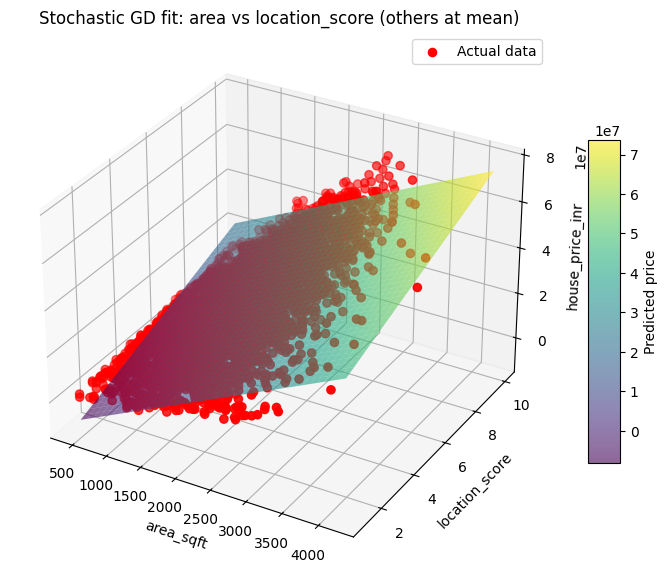

In [54]:

# Fix two features at their mean so we can plot a 2D surface
mean_bed = df.bedrooms.mean()
mean_bath = df.bathrooms.mean()

area_grid = np.linspace(df.area_sqft.min(), df.area_sqft.max(), 40)
loc_grid  = np.linspace(df.location_score.min(), df.location_score.max(), 40)
A, L = np.meshgrid(area_grid, loc_grid)

grid_rows = np.c_[A.ravel(),
                  np.full(A.size, mean_bed),
                  np.full(A.size, mean_bath),
                  L.ravel()]

Z = predict(grid_rows).reshape(A.shape)  # predicted prices from SGD model

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

# Model surface
surf = ax.plot_surface(A, L, Z, cmap="viridis", alpha=0.6, linewidth=0, antialiased=True)

# Actual data
ax.scatter(df.area_sqft, df.location_score, df.house_price_inr,
           color="red", s=35, label="Actual data", depthshade=True)

ax.set_xlabel("area_sqft")
ax.set_ylabel("location_score")
ax.set_zlabel("house_price_inr")
ax.set_title("Stochastic GD fit: area vs location_score (others at mean)")
ax.legend()
fig.colorbar(surf, shrink=0.6, aspect=10, label="Predicted price")
plt.show()
